# Introduction to Machine Learning: Deep Learning

**Instructor:** Daniel Acuna, Ph.D.
**Position:** Associate Professor of Computer Science
**Institution:** University of Colorado Boulder

---

# Lab 5: Transformers and Vision Transformers

In this lab, you will explore the core components of the Transformer architecture, including
positional encoding, self-attention, and layer normalization. You will then build a simple
Vision Transformer (ViT) to classify Fashion MNIST images by treating image patches as tokens.

**Topics Covered:**
- Positional encoding
- Scaled dot-product attention
- Multi-head attention
- Layer normalization
- Vision Transformer (ViT) architecture
- Comparing encoder-only vs decoder-only Transformers

---

## Setup (do not edit)

In [1]:
import pathlib
from typing import Tuple, Dict, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization, MultiHeadAttention,
    Layer, Embedding, Add, GlobalAveragePooling1D, Flatten, Reshape
)

# Suppress TensorFlow warnings
tf.get_logger().setLevel("ERROR")

RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

_DATA_PATH = pathlib.Path("fashion_mnist_vit.csv")

if not _DATA_PATH.exists():
    raise FileNotFoundError(
        "fashion_mnist_vit.csv is missing. Please run the download script (w5_download_datasets.py) "
        "or ask the TA for assistance."
    )

# Class names for Fashion MNIST
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

## 1. Load and Prepare Image Data *(10 points)*

Load the Fashion MNIST dataset and prepare it for the Vision Transformer.

**Tasks:**
1. Load the CSV file into a DataFrame.
2. Separate training and test data using the `split` column.
3. Extract labels (`y_train`, `y_test`) and pixel values.
4. Reshape images to 28×28 and normalize pixel values to [0, 1].
5. Store the training images in **`X_train`** and test images in **`X_test`**.
6. Store the shape of `X_train` in **`q1_shape`**.

Training data shape: (10000, 28, 28)
Test data shape: (2000, 28, 28)
Number of classes: 10


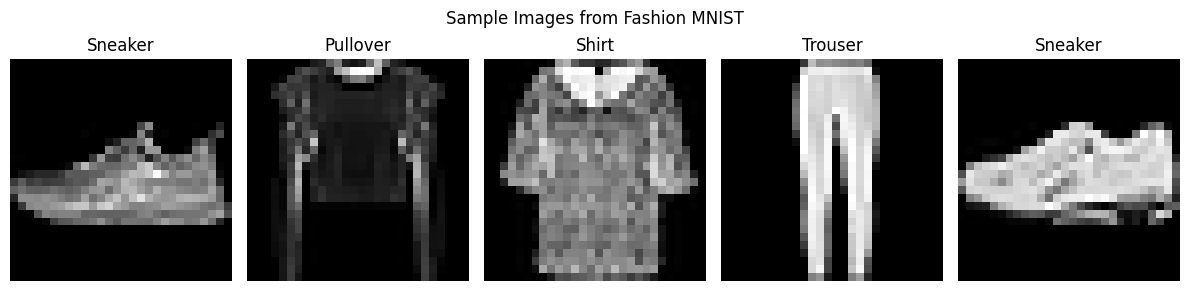

In [2]:
def load_and_prepare_data(path: pathlib.Path) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Load and prepare image data from CSV.
    
    Parameters
    ----------
    path : pathlib.Path
        Path to the CSV file.
        
    Returns
    -------
    Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]
        X_train, X_test, y_train, y_test
    """
    # Read csv into one df - train and test rows are mixed together and distinguished by split column 
    df = pd.read_csv(path)

    #split into train / test 
    train_df = df[df['split'] == 'train']
    test_df = df[df['split'] == 'test']
    
    # every col except 'split' and 'label' is a pixel val. This avoids hardcoding 'pixel0', 'pixel1' into col names
    pixel_cols = [c for c in df.columns if c not in ('split', 'label')]
    
    # pull out label for each split
    y_train = train_df['label'].to_numpy()
    y_test = test_df['label'].to_numpy()
    
    # Get the pixel columns as a 2D array (samples x 784), reshape each row into 28x28 image, cast as float
    #   and normalize from [0, 255] to [0, 1]
    X_train = train_df[pixel_cols].to_numpy().reshape(-1, 28, 28).astype(np.float32) / 255.0
    X_test = test_df[pixel_cols].to_numpy().reshape(-1, 28, 28).astype(np.float32) / 255.0
    
    
    return X_train, X_test, y_train, y_test
    
    
    
X_train, X_test, y_train, y_test = load_and_prepare_data(_DATA_PATH)
q1_shape: Tuple[int, int, int] = X_train.shape

print(f"Training data shape: {q1_shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")

# Visualize some samples
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(CLASS_NAMES[y_train[i]])
    ax.axis('off')
plt.suptitle("Sample Images from Fashion MNIST")
plt.tight_layout()
plt.show()

In [3]:
# If all tests pass (there might be hidden tests), you will earn 10 points
assert isinstance(X_train, np.ndarray), "X_train must be a numpy array"
assert isinstance(q1_shape, tuple), "q1_shape must be a tuple"
assert len(q1_shape) == 3, "Images should be 3-dimensional (samples, height, width)"
assert X_train.max() <= 1.0 and X_train.min() >= 0.0, "Pixel values should be normalized to [0, 1]"
assert q1_shape[1] == 28 and q1_shape[2] == 28, "Images should be 28x28"


## 2. Positional Encoding *(10 points)*

Transformers process sequences in parallel and have no inherent notion of order.
Positional encoding adds position information to the input embeddings.

The original Transformer uses sinusoidal positional encoding:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

**Task:**
Implement a function `create_positional_encoding(seq_len, d_model)` that returns
a positional encoding matrix of shape `(seq_len, d_model)`.

Store the positional encoding for `seq_len=49` and `d_model=64` in **`q2_pos_enc`**.

Positional encoding shape: (49, 64)


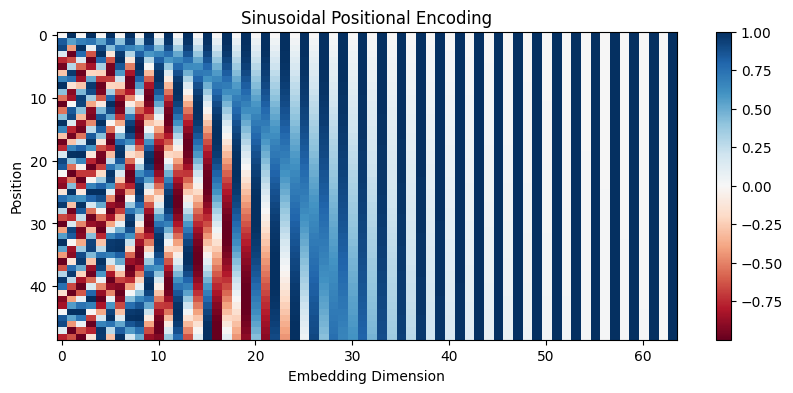

In [4]:
def create_positional_encoding(seq_len: int, d_model: int) -> np.ndarray:
    """Create sinusoidal positional encoding.
    
    Parameters
    ----------
    seq_len : int
        Sequence length (number of positions).
    d_model : int
        Embedding dimension.
        
    Returns
    -------
    np.ndarray
        Positional encoding of shape (seq_len, d_model).
    """
    # Column vector of positions: 0, 1, ... , seq_len - 1
    # Shape (seq_len, 1) so it broadcasts against dims below
    positions = np.arange(seq_len)[:, np.newaxis]
    
    # Row vector of embedding-dim indices: 0, 1, ..., d_model - 1
    dims = np.arange(d_model)[np.newaxis, :]
    
    # Formual uses 2i (pairs of dims share same freq) so dims // 2 turns into [0,0,1,1...]
    # so then gives the denominator 10000^(2i/d_model) from that formula 
    angle_rates = 1.0 / np.power(10000, (2 * (dims // 2)) / np.float32(d_model))
    
    # multiply pos's by angle_rate 
    #    (broadcasting (seq_len, 1) * (1, d_model)) -> (seq_len, d_model) 
    #       for every pos/dim pair
    angle_rads = positions * angle_rates
    
    # Even indices get sin, odd indices get cos
    pos_encoding = np.zeros_like(angle_rads)
    pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])   # PE(pos, 2i)
    pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])   # PE(pos, 2i + 1)
    
    
    return pos_encoding

# For ViT with 7x7 patches on 28x28 images: 49 patches
SEQ_LEN = 49
D_MODEL = 64

q2_pos_enc: np.ndarray = create_positional_encoding(SEQ_LEN, D_MODEL)

print(f"Positional encoding shape: {q2_pos_enc.shape}")

# Visualize the positional encoding
plt.figure(figsize=(10, 4))
plt.imshow(q2_pos_enc, aspect='auto', cmap='RdBu')
plt.xlabel('Embedding Dimension')
plt.ylabel('Position')
plt.title('Sinusoidal Positional Encoding')
plt.colorbar()
plt.show()

In [5]:
# If all tests pass (there might be hidden tests), you will earn 10 points
assert isinstance(q2_pos_enc, np.ndarray), "q2_pos_enc must be a numpy array"
assert q2_pos_enc.shape == (SEQ_LEN, D_MODEL), f"Shape should be ({SEQ_LEN}, {D_MODEL})"
assert np.abs(q2_pos_enc).max() <= 1.0, "Values should be between -1 and 1"

# Check that sin/cos pattern is correct
assert np.isclose(q2_pos_enc[0, 0], 0.0, atol=0.01), "PE[0,0] should be sin(0) = 0"
assert np.isclose(q2_pos_enc[0, 1], 1.0, atol=0.01), "PE[0,1] should be cos(0) = 1"


## 3. Scaled Dot-Product Attention *(10 points)*

The core of the Transformer is the attention mechanism:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Task:**
Implement the `scaled_dot_product_attention` function.

Create test tensors and compute attention. Store:
- **`q3_attention_weights`**: The attention weights (after softmax)
- **`q3_output`**: The output of the attention mechanism

In [8]:
def scaled_dot_product_attention(
    query: np.ndarray, 
    key: np.ndarray, 
    value: np.ndarray
) -> Tuple[np.ndarray, np.ndarray]:
    """Compute scaled dot-product attention.
    
    Parameters
    ----------
    query : np.ndarray
        Query matrix of shape (seq_len, d_k).
    key : np.ndarray
        Key matrix of shape (seq_len, d_k).
    value : np.ndarray
        Value matrix of shape (seq_len, d_v).
        
    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        (output, attention_weights)
        - output: shape (seq_len, d_v)
        - attention_weights: shape (seq_len, seq_len)
    """
    # d_k is the key/query dimension, used to scale the dot products so they dont grow too large
    #   as d_k increases (keeps softmax gradients like 'well behaved')
    d_k = query.shape[-1]
    
    # QK^T: for every query, a similarity score against every key, query is (seq_len, d_k),
    #   key.T is (d_k, seq_len) -> scores (seq_len, seq_len). 
    # Divide by sqrt(d_k) 
    scores = query @ key.T / np.sqrt(d_k)
    
    # Softmax over the last axis (each row = one query's scored axross all kets), so each row of
    #   attention_weights sums to 1. Subtracting the row max before exponentiating is a normal
    #   numerical stablility trick
    scores_stable = scores - np.max(scores, axis = -1, keepdims = True)
    exp_scores = np.exp(scores_stable)
    attention_weights = exp_scores / np.sum(exp_scores, axis = -1, keepdims = True)
    
    # Weighted sum of the val vectors, weighted by attention_weights, 
    #    (seq_len, seq_len) @ (seq_len, d_v) -> (seq_len, d_v)
    output = attention_weights @ value

    return output, attention_weights


# Test with simple example
np.random.seed(RANDOM_STATE)
test_seq_len = 4
test_d_k = 8

Q = np.random.randn(test_seq_len, test_d_k).astype(np.float32)
K = np.random.randn(test_seq_len, test_d_k).astype(np.float32)
V = np.random.randn(test_seq_len, test_d_k).astype(np.float32)

q3_output, q3_attention_weights = scaled_dot_product_attention(Q, K, V)

print(f"Attention weights shape: {q3_attention_weights.shape}")
print(f"Output shape: {q3_output.shape}")
print(f"Attention weights (rows sum to 1):\n{q3_attention_weights}")

Attention weights shape: (4, 4)
Output shape: (4, 8)
Attention weights (rows sum to 1):
[[0.08431244 0.25513027 0.51521077 0.14534652]
 [0.64059207 0.13328609 0.01664257 0.20947927]
 [0.47006415 0.08789379 0.11121405 0.33082801]
 [0.1779445  0.49185019 0.20052305 0.12968226]]


In [9]:
# If all tests pass (there might be hidden tests), you will earn 10 points
assert q3_attention_weights.shape == (test_seq_len, test_seq_len), "Attention weights shape incorrect"
assert q3_output.shape == (test_seq_len, test_d_k), "Output shape incorrect"

# Check that attention weights sum to 1 along the key dimension
row_sums = np.sum(q3_attention_weights, axis=-1)
assert np.allclose(row_sums, 1.0, atol=1e-5), "Attention weights must sum to 1 for each query"

# Check that all weights are non-negative
assert np.all(q3_attention_weights >= 0), "Attention weights must be non-negative"


## 4. Layer Normalization *(10 points)*

Layer normalization normalizes across features for each sample:

$$\text{LayerNorm}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

Unlike batch normalization, layer norm:
- Normalizes across features (not batch)
- Works with any batch size
- Is ideal for sequence models

**Task:**
Implement `layer_norm(x, gamma, beta, epsilon)` that applies layer normalization.
Compute the mean and variance across the last axis (features).

Store the result of applying layer norm to a test array in **`q4_normalized`**.

In [10]:
def layer_norm(
    x: np.ndarray, 
    gamma: np.ndarray, 
    beta: np.ndarray, 
    epsilon: float = 1e-6
) -> np.ndarray:
    """Apply layer normalization.
    
    Parameters
    ----------
    x : np.ndarray
        Input array of shape (..., features).
    gamma : np.ndarray
        Scale parameter of shape (features,).
    beta : np.ndarray
        Shift parameter of shape (features,).
    epsilon : float
        Small constant for numerical stability.
        
    Returns
    -------
    np.ndarray
        Normalized array, same shape as input.
    """
    # Mean and variance across the last axis (feature), per sample
    mean = x.mean(axis = -1, keepdims = True)
    var = x.var(axis = -1, keepdims = True)
    
    # Normalize, then scale by gamma and shift by beta
    x_norm = (x - mean) / np.sqrt(var + epsilon)
    return gamma * x_norm + beta

# Test layer normalization
np.random.seed(RANDOM_STATE)
test_input = np.random.randn(3, 8).astype(np.float32) * 10 + 5  # Mean ~5, varied values
gamma = np.ones(8, dtype=np.float32)
beta = np.zeros(8, dtype=np.float32)

q4_normalized: np.ndarray = layer_norm(test_input, gamma, beta)

print(f"Input mean per sample: {test_input.mean(axis=-1)}")
print(f"Normalized mean per sample: {q4_normalized.mean(axis=-1)}")
print(f"Normalized std per sample: {q4_normalized.std(axis=-1)}")

Input mean per sample: [10.509407  -1.0182317  1.0796759]
Normalized mean per sample: [-2.9802322e-08 -1.4901161e-08  1.4901161e-08]
Normalized std per sample: [1. 1. 1.]


In [11]:
# If all tests pass (there might be hidden tests), you will earn 10 points
assert q4_normalized.shape == test_input.shape, "Shape should be preserved"

# After normalization with gamma=1, beta=0, each sample should have mean≈0, std≈1
sample_means = q4_normalized.mean(axis=-1)
sample_stds = q4_normalized.std(axis=-1)
assert np.allclose(sample_means, 0, atol=1e-5), "Normalized samples should have mean ≈ 0"
assert np.allclose(sample_stds, 1, atol=0.1), "Normalized samples should have std ≈ 1"


## 5. Patch Embedding for Vision Transformer *(10 points)*

Vision Transformers split images into fixed-size patches and linearly project each patch.

For a 28×28 image with 4×4 patches:
- Number of patches = (28/4) × (28/4) = 7 × 7 = 49
- Each patch has 4 × 4 = 16 pixels

**Task:**
Implement `extract_patches(images, patch_size)` that:
1. Splits each image into non-overlapping patches.
2. Flattens each patch into a vector.
3. Returns shape `(batch_size, num_patches, patch_dim)`.

Store the patches for the first 100 training images with `patch_size=4` in **`q5_patches`**.

Patches shape: (100, 49, 16)
Expected: (100, 49, 16)


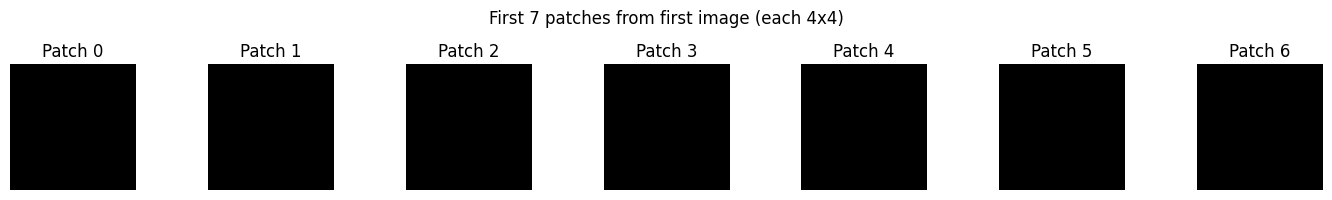

In [14]:
def extract_patches(images: np.ndarray, patch_size: int) -> np.ndarray:
    """Extract non-overlapping patches from images.
    
    Parameters
    ----------
    images : np.ndarray
        Images of shape (batch_size, height, width).
    patch_size : int
        Size of each square patch.
        
    Returns
    -------
    np.ndarray
        Patches of shape (batch_size, num_patches, patch_dim).
        patch_dim = patch_size * patch_size
    """
    batch_size, height, width = images.shape
    grid_size = height // patch_size        # patches per row/col (7 for 28/4)
    num_patches = grid_size * grid_size     # 49
    patch_dim = patch_size * patch_size     # 16
    
    # Split H and W into (grid, patch_size) each:
    #  (batch, grid_h, patch_h, grid_w, grid_w)
    patches = images.reshape(batch_size, grid_size, patch_size, grid_size, patch_size)
    
    # Bring the 2 grid axes together and the 2 in-patch axes together:
    #  (batch, grid_h, grid_w, patch_h, patch_w)
    patches = patches.transpose(0, 1, 3, 2, 4)
    
    # now we flatten grid dims -> num_patches, and in-patch dims -> patch_dim
    patches = patches.reshape(batch_size, num_patches, patch_dim)
    
    return patches
    
    
PATCH_SIZE = 4
q5_patches: np.ndarray = extract_patches(X_train[:100], PATCH_SIZE)

print(f"Patches shape: {q5_patches.shape}")
print(f"Expected: (100, 49, 16)")

# Visualize patches from first image
fig, axes = plt.subplots(1, 7, figsize=(14, 2))
fig.suptitle("First 7 patches from first image (each 4x4)")
for i in range(7):
    patch = q5_patches[0, i].reshape(PATCH_SIZE, PATCH_SIZE)
    axes[i].imshow(patch, cmap='gray')
    axes[i].set_title(f"Patch {i}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [15]:
# If all tests pass (there might be hidden tests), you will earn 10 points
expected_num_patches = (28 // PATCH_SIZE) ** 2  # 49
expected_patch_dim = PATCH_SIZE ** 2  # 16

assert q5_patches.shape == (100, expected_num_patches, expected_patch_dim), (
    f"Shape should be (100, {expected_num_patches}, {expected_patch_dim})"
)

# Check that patches reconstruct to original image
reconstructed = q5_patches[0].reshape(7, 7, 4, 4).transpose(0, 2, 1, 3).reshape(28, 28)
assert np.allclose(reconstructed, X_train[0]), "Patches should reconstruct to original image"


## 6. Build a Simple Vision Transformer *(15 points)*

Now let's build a simple Vision Transformer using Keras:

**Architecture:**
1. Input: Flattened patches of shape `(num_patches, patch_dim)`
2. Linear projection to `embed_dim=64`
3. Add positional encoding (as a Dense layer input)
4. Transformer encoder block:
   - `MultiHeadAttention` with `num_heads=4`, `key_dim=16`
   - Skip connection + `LayerNormalization`
   - `Dense(128, relu)` + `Dense(embed_dim)`
   - Skip connection + `LayerNormalization`
5. `GlobalAveragePooling1D` to aggregate patches
6. `Dense(64, relu)` + `Dropout(0.3)`
7. Output: `Dense(10, softmax)` for 10 classes

Store the model in **`model_vit`**.

In [18]:
# Model parameters
NUM_PATCHES = 49  # 7x7 patches
PATCH_DIM = 16    # 4x4 flattened
EMBED_DIM = 64
NUM_HEADS = 4
KEY_DIM = 16
FF_DIM = 128
NUM_CLASSES = 10

# input: flatten patches, shape (num_patches, patch_dim) per sample
inputs = Input(shape = (NUM_PATCHES, PATCH_DIM))

# Linear projection: project each patch vecotr from patch_dim -> embed_dim
x = Dense(EMBED_DIM)(inputs)

# Positional encoding: reuse the sin encoding from before (create_positional_encoding), build once
#   as a fixed (non trainable) constant tensor, then added to the projected patches so the model
#   knows each patchs pos in the grid
pos_encoding_np = create_positional_encoding(NUM_PATCHES, EMBED_DIM)
pos_encoding = tf.constant(pos_encoding_np, dtype = tf.float32)
x = tf.keras.layers.Lambda(
    lambda t: t + pos_encoding,
    output_shape = (NUM_PATCHES, EMBED_DIM)
)(x)

# TRANSFORMER ENCODER BLOCK #

# Self attention: each patch attends to every other patch
attn_output = MultiHeadAttention(num_heads = NUM_HEADS, key_dim = KEY_DIM)(x, x)

# Skip residual connection around attention, then normalize
x1 = Add()([x, attn_output])
x1 = LayerNormalization()(x1)

# Feed forward network: expand to FF_DIM then project back to EMBED_DIM
ffn = Dense(FF_DIM, activation = 'relu')(x1)
ffn = Dense(EMBED_DIM)(ffn)

# Skip connection around the FFN, then normalize
x2 = Add()([x1, ffn])
x2 = LayerNormalization()(x2)

# agg all patch tokens into one vector per image by avg'ing across the pathcs
x = GlobalAveragePooling1D()(x2)

# Classification 
x = Dense(64, activation = 'relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation = 'softmax')(x)

model_vit = Model(inputs = inputs, outputs = outputs)
model_vit.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',       # labels are int class ids
    metrics = ['accuracy'],
)



model_vit.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 49, 16)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 49, 64)    │      1,088 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 49, 64)    │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 64)    │     16,640 │ lambda[0][0],     │
│ (MultiHeadAttentio… │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 49, 64)    │          0 │ lambda[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 49, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 49, 64)    │      8,256 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 49, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 10)        │        650 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,370 (153.79 KB)

 Trainable params: 39,370 (153.79 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# If all tests pass (there might be hidden tests), you will earn 15 points
assert isinstance(model_vit, Model), "model_vit must be a Keras Model"

# Check for required layers
layer_types = [type(layer).__name__ for layer in model_vit.layers]
assert 'MultiHeadAttention' in layer_types, "Model must include MultiHeadAttention"
assert 'LayerNormalization' in layer_types, "Model must include LayerNormalization"
assert 'GlobalAveragePooling1D' in layer_types, "Model must include GlobalAveragePooling1D"

# Check input and output shapes
assert model_vit.input_shape == (None, NUM_PATCHES, PATCH_DIM), "Input shape incorrect"
assert model_vit.output_shape == (None, NUM_CLASSES), "Output should have 10 classes"


## 7. Train the Vision Transformer *(10 points)*

Prepare the data and train the ViT model.

**Tasks:**
1. Extract patches from training and test images.
2. Train for **3 epochs** with `batch_size=64`.
3. Store the training history in **`history_vit`**.
4. Store the final validation accuracy (rounded to 3 decimals) in **`q7_val_acc`**.

In [21]:
# Extract patches from training and test images (this reuses extract_pathes from before)
X_train_patches = extract_patches(X_train, PATCH_SIZE)
X_test_patches = extract_patches(X_test, PATCH_SIZE)

# Train for 3 epochs, tracking validation 
history_vit = model_vit.fit(
    X_train_patches, y_train,
    validation_data = (X_test_patches, y_test),
    epochs = 3,
    batch_size = 64,
)

# final validation acc from the last epoch
q7_val_acc = round(history_vit.history['val_accuracy'][-1], 3)

print(f"Final validation accuracy: {q7_val_acc}")

Epoch 1/3
 79/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1728 - loss: 2.1944 

I0000 00:00:1790377851.506667     323 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


157/157 ━━━━━━━━━━━━━━━━━━━━ 79s 264ms/step - accuracy: 0.3191 - loss: 1.8066 - val_accuracy: 0.5715 - val_loss: 1.1963
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6017 - loss: 1.0871 - val_accuracy: 0.6715 - val_loss: 0.9027
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6624 - loss: 0.9271 - val_accuracy: 0.6845 - val_loss: 0.8447
Final validation accuracy: 0.684


In [22]:
# If all tests pass (there might be hidden tests), you will earn 10 points
assert 'val_accuracy' in history_vit.history, "History should contain val_accuracy"
assert len(history_vit.history['loss']) == 3, "Should train for 3 epochs"
print(f"Vision Transformer Val Acc: {q7_val_acc}")


Vision Transformer Val Acc: 0.684


## 8. Compare with a Simple CNN *(10 points)*

Let's compare the ViT with a simple Convolutional Neural Network.

**Task:**
Build a simple CNN with:
1. `Input` layer: shape=(28, 28, 1)
2. `Conv2D(32, 3, relu, padding='same')` + `MaxPooling2D(2)`
3. `Conv2D(64, 3, relu, padding='same')` + `MaxPooling2D(2)`
4. `Flatten`
5. `Dense(64, relu)` + `Dropout(0.3)`
6. `Dense(10, softmax)`

Train for **3 epochs** with `batch_size=64`.

Store the model in **`model_cnn`**, history in **`history_cnn`**, and validation accuracy in **`q8_val_acc`**.

In [24]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D

# CNNs expect an explicit channel dim: (28, 28) -> (28, 28, 1)
X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

model_cnn = tf.keras.Sequential([
    Input(shape = (28, 28, 1)),
    
    # 1st conv block: 32 filters, 3x3 kernel, same padding, then downsample by 2x2 maxpooling
    Conv2D(32, 3, activation = 'relu', padding = 'same'),
    MaxPooling2D(2),
    
    # 2nd conv block
    Conv2D(64, 3, activation = 'relu', padding = 'same'),
    MaxPooling2D(2),
    
    # Flatten feature maps into single vector for dense layers
    Flatten(),
    Dense(64, activation = 'relu'),
    Dropout(0.3),
    
    # 10 way classification
    Dense(10, activation = 'softmax')    
])

model_cnn.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'],
)

# train for 3 epochs, same batch size as vit for comparison
history_cnn = model_cnn.fit(
    X_train_cnn, y_train,
    validation_data = (X_test_cnn, y_test),
    epochs = 3, 
    batch_size = 64,
    
)

q8_val_acc = round(history_cnn.history['val_accuracy'][-1], 3)

print(f"CNN Validation Accuracy: {q8_val_acc}")

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.6530 - loss: 0.9687 - val_accuracy: 0.7905 - val_loss: 0.5671
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8001 - loss: 0.5733 - val_accuracy: 0.8325 - val_loss: 0.4600
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8302 - loss: 0.4883 - val_accuracy: 0.8455 - val_loss: 0.4278
CNN Validation Accuracy: 0.845


In [25]:
# If all tests pass (there might be hidden tests), you will earn 10 points
assert isinstance(model_cnn, Model), "model_cnn must be a Keras Model"
layer_types_cnn = [type(layer).__name__ for layer in model_cnn.layers]
assert 'Conv2D' in layer_types_cnn, "CNN must include Conv2D layers"
assert 'MaxPooling2D' in layer_types_cnn, "CNN must include MaxPooling2D layers"

print(f"CNN Val Acc: {q8_val_acc}")


CNN Val Acc: 0.845


## 9. Understanding BERT vs GPT Architecture *(5 points)*

Based on what you learned about BERT (encoder-only) and GPT (decoder-only):

**Task:**
Answer the following by setting the appropriate variables:

1. **`q9_bert_direction`**: BERT uses which type of attention?
   - `'bidirectional'` or `'causal'`

2. **`q9_gpt_direction`**: GPT uses which type of attention?
   - `'bidirectional'` or `'causal'`

3. **`q9_bert_task`**: BERT is better suited for which type of task?
   - `'understanding'` or `'generation'`

4. **`q9_gpt_task`**: GPT is better suited for which type of task?
   - `'understanding'` or `'generation'`

In [31]:
q9_bert_direction = 'bidirectional'
q9_gpt_direction = 'causal'
q9_bert_task = 'understanding'
q9_gpt_task = 'generation'

print(f"BERT attention: {q9_bert_direction}")
print(f"GPT attention: {q9_gpt_direction}")
print(f"BERT best for: {q9_bert_task}")
print(f"GPT best for: {q9_gpt_task}")

BERT attention: bidirectional
GPT attention: causal
BERT best for: understanding
GPT best for: generation


In [33]:
# If all tests pass (there might be hidden tests), you will earn 5 points
assert q9_bert_direction in ['bidirectional', 'causal'], "Must be 'bidirectional' or 'causal'"
assert q9_gpt_direction in ['bidirectional', 'causal'], "Must be 'bidirectional' or 'causal'"
assert q9_bert_task in ['understanding', 'generation'], "Must be 'understanding' or 'generation'"
assert q9_gpt_task in ['understanding', 'generation'], "Must be 'understanding' or 'generation'"


## 10. Model Comparison and Analysis *(10 points)*

Compare the performance and characteristics of the ViT and CNN models.

**Task:**
1. Create a dictionary **`q10_results`** with keys `'ViT'` and `'CNN'` containing their validation accuracies.
2. Determine which model performed better and store in **`q10_best_model`**.
3. Store the number of trainable parameters in each model:
   - **`q10_vit_params`**: Number of trainable parameters in ViT
   - **`q10_cnn_params`**: Number of trainable parameters in CNN

Model Comparison:
  ViT: 0.684 accuracy, 39,370 parameters
  CNN: 0.845 accuracy, 220,234 parameters
Best model: CNN


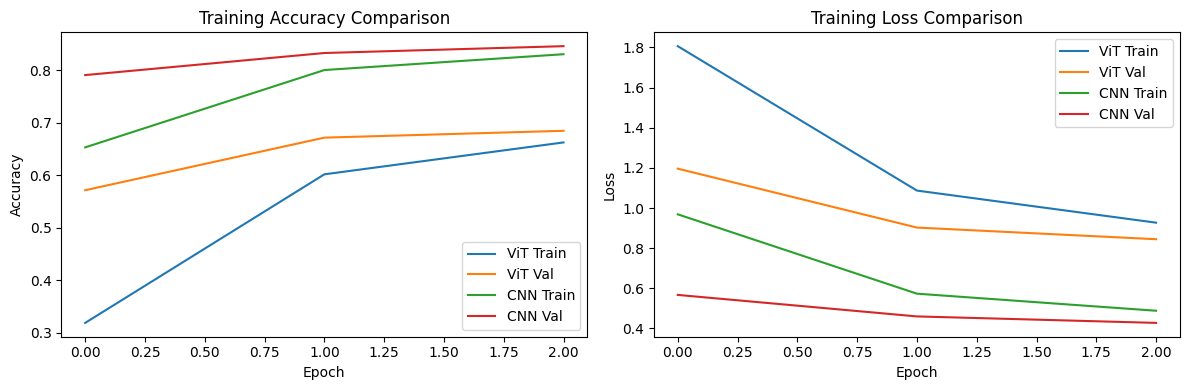

In [35]:
# Finally pull validation acc for each model
q10_results = {
    'ViT': history_vit.history['val_accuracy'][-1],
    'CNN': history_cnn.history['val_accuracy'][-1]
}

# find which has the higher validation acc rate
q10_best_model = 'ViT' if q10_results['ViT'] > q10_results['CNN'] else 'CNN'

# count trainable params for each model
q10_vit_params = (
            int(np.sum([tf.keras.backend.count_params(w) for w in model_vit.trainable_weights]))
)
q10_cnn_params = (
            int(np.sum([tf.keras.backend.count_params(w) for w in model_cnn.trainable_weights]))
)

print("Model Comparison:")
print(f"  ViT: {q10_results['ViT']:.3f} accuracy, {q10_vit_params:,} parameters")
print(f"  CNN: {q10_results['CNN']:.3f} accuracy, {q10_cnn_params:,} parameters")
print(f"Best model: {q10_best_model}")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_vit.history['accuracy'], label='ViT Train')
axes[0].plot(history_vit.history['val_accuracy'], label='ViT Val')
axes[0].plot(history_cnn.history['accuracy'], label='CNN Train')
axes[0].plot(history_cnn.history['val_accuracy'], label='CNN Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training Accuracy Comparison')
axes[0].legend()

axes[1].plot(history_vit.history['loss'], label='ViT Train')
axes[1].plot(history_vit.history['val_loss'], label='ViT Val')
axes[1].plot(history_cnn.history['loss'], label='CNN Train')
axes[1].plot(history_cnn.history['val_loss'], label='CNN Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training Loss Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

In [36]:
# If all tests pass (there might be hidden tests), you will earn 10 points
assert isinstance(q10_results, dict), "q10_results must be a dictionary"
assert 'ViT' in q10_results and 'CNN' in q10_results, "Must include both models"
assert isinstance(q10_best_model, str), "q10_best_model must be a string"
assert q10_best_model in ['ViT', 'CNN'], "Best model must be 'ViT' or 'CNN'"
assert isinstance(q10_vit_params, int), "Parameter count must be an integer"
assert isinstance(q10_cnn_params, int), "Parameter count must be an integer"

print("Model analysis complete!")
print(f"ViT parameters: {q10_vit_params:,}")
print(f"CNN parameters: {q10_cnn_params:,}")


Model analysis complete!
ViT parameters: 39,370
CNN parameters: 220,234


## Next Steps

Congratulations on completing the assignment! Before submitting:

1. Make sure all your cells run without errors.
2. Ensure you've answered all parts of each question.
3. If any autograder tests fail, revisit your answers.